# 1.Write a Python script using pandas and scikit-learn to load a dataset, perform a 70/30 train/test split, and apply standard scaling (StandardScaler) to the feature columns. 

In [3]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

file_path = os.path.expanduser(r"~\Downloads\USA_Housing.csv")
df = pd.read_csv(file_path)

df = df.dropna()
df = pd.get_dummies(df, drop_first=True)

target_col = "median_house_value" if "median_house_value" in df.columns else df.columns[-1]

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(
    X_train_scaled, columns=X.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    X_test_scaled, columns=X.columns, index=X_test.index
)

print("Train shape:", X_train_scaled.shape)
print("Test shape: ", X_test_scaled.shape)

Train shape: (3500, 5004)
Test shape:  (1500, 5004)


# 2.Using matplotlib and seaborn, write a function that takes a pandas DataFrame and a column name as input, and plots both a boxplot and a scatter plot to visually identify outliers and distribution patterns. 

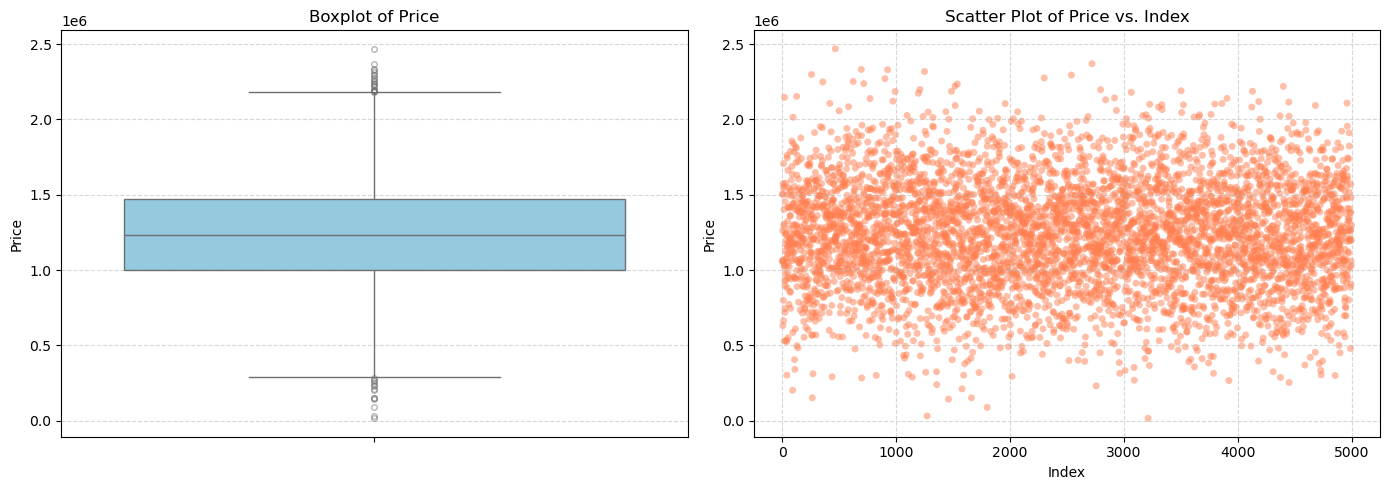

In [6]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


def plot_outliers_and_distribution(df, column_name):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.boxplot(
        y=df[column_name],
        ax=axes[0],
        color="skyblue",
        flierprops={"marker": "o", "markersize": 4, "alpha": 0.5},
    )
    axes[0].set_title(f"Boxplot of {column_name}")
    axes[0].set_ylabel(column_name)
    axes[0].grid(axis="y", linestyle="--", alpha=0.5)

    axes[1].scatter(
        df.index,
        df[column_name],
        alpha=0.5,
        color="coral",
        edgecolor="none",
        s=25,
    )
    axes[1].set_title(f"Scatter Plot of {column_name} vs. Index")
    axes[1].set_xlabel("Index")
    axes[1].set_ylabel(column_name)
    axes[1].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()


file_path = os.path.expanduser(r"~\Downloads\USA_Housing.csv")
df = pd.read_csv(file_path)

plot_outliers_and_distribution(df, "Price")
  

# 3. Implement a linear regression model using scikit-learn's LinearRegression on a housing dataset. Calculate and print the Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and R² score on the test set. 

In [7]:
import os
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

file_path = os.path.expanduser(r"~\Downloads\USA_Housing.csv")
df = pd.read_csv(file_path)

numeric_df = df.select_dtypes(include=["number"])

X = numeric_df.drop(columns=["Price"])
y = numeric_df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

try:
    rmse = root_mean_squared_error(y_test, y_pred)
except (NameError, AttributeError):
    rmse = mean_squared_error(y_test, y_pred, squared=False)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"R² Score:                       {r2:.4f}")

Root Mean Squared Error (RMSE): 100341.5295
Mean Absolute Error (MAE):      81135.5661
R² Score:                       0.9147


# 4. Write a Python program to load the Iris dataset, train a LogisticRegression model, and output the predicted classes for the test dataset. 

In [8]:
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predicted class indices:")
print(y_pred)

print("\nPredicted class names:")
print(iris.target_names[y_pred])

Predicted class indices:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]

Predicted class names:
['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'setosa' 'setosa' 'virginica' 'versicolor'
 'setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'setosa']


# 5. Implement a K-Nearest Neighbors (KNN) classifier with n_neighbors=5. After training and testing the model, write the code to compute and display its confusion matrix using scikit-learn utilities. 

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


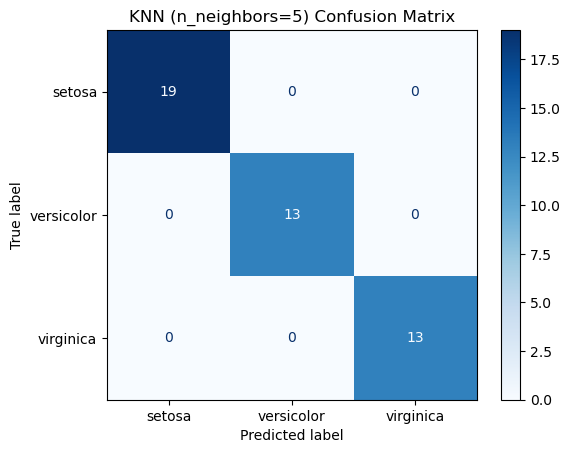

In [9]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap="Blues")
plt.title("KNN (n_neighbors=5) Confusion Matrix")
plt.show()

# 6. Write a script to compare a single Decision Tree Classifier against a Random Forest Classifier on a binary classification dataset. Print the accuracy score of both models to determine which performed better. 

In [10]:
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)

dt_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

if rf_accuracy > dt_accuracy:
    print("Random Forest performed better.")
elif dt_accuracy > rf_accuracy:
    print("Decision Tree performed better.")
else:
    print("Both models achieved the same accuracy.")

Decision Tree Accuracy: 0.9415
Random Forest Accuracy: 0.9708
Random Forest performed better.


# 7. Given a set of true labels and predicted labels, write code to manually calculate or use scikit-learn to extract the precision, recall, and F1-score for a specific target class without using the full classification_report. 

In [12]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = [0, 1, 2, 0, 1, 2, 1, 0, 2, 1]
y_pred = [0, 2, 2, 0, 1, 1, 1, 0, 2, 2]

target_class = 1

precision = precision_score(y_true, y_pred, labels=[target_class], average=None)[0]
recall = recall_score(y_true, y_pred, labels=[target_class], average=None)[0]
f1 = f1_score(y_true, y_pred, labels=[target_class], average=None)[0]

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")

Precision: 0.6667
Recall:    0.5000
F1-Score:  0.5714


# 8. Implement a 5-fold cross-validation routine using KFold and cross_val_score to evaluate the stability of a Ridge regression model on a continuous target variable. 

In [13]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score

X, y = make_regression(n_samples=500, n_features=10, noise=0.2, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = Ridge(alpha=1.0)

scores = cross_val_score(model, X, y, cv=kf, scoring="r2")

print("Fold R² scores:", np.round(scores, 4))
print(f"Mean R²:       {np.mean(scores):.4f}")
print(f"Std Deviation: {np.std(scores):.4f}")

Fold R² scores: [1. 1. 1. 1. 1.]
Mean R²:       1.0000
Std Deviation: 0.0000


# 9. Write a Python snippet utilizing GridSearchCV to find the optimal hyperparameters for a Random Forest Classifier. Search across n_estimators ([50, 100, 200]) and max_depth ([None, 10, 20]). 

In [16]:
from sklearn.datasets import load_wine
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

data = load_wine()
X, y = data.data, data.target

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X, y)

print(f"Optimal Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy:   {grid_search.best_score_:.4f}")

Optimal Parameters: {'max_depth': None, 'n_estimators': 100}
Best CV Accuracy:   0.9721
